# Usage modules

Pipeline Modules:
Input -> Splitter -> Estimators -> Normalize Constants -> Distance
-> Kernel Adapter -> Kernel -> Optimize + Loss -> Aggregation -> Output

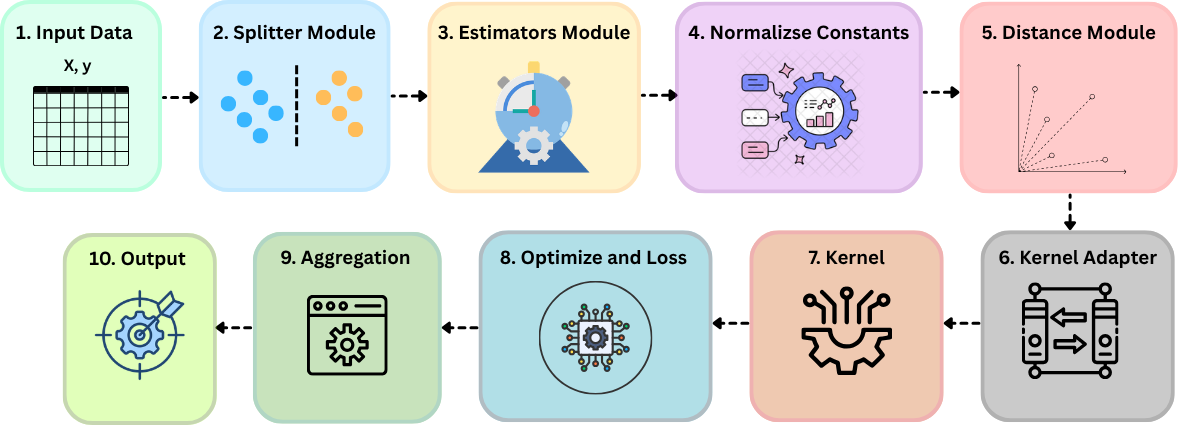

## Prepare data

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)

(569, 30) (569,)


## Splitter Module

In [2]:
from cobra.core.splitters.base import SplitterFactory

splitter = SplitterFactory.create(
    "holdout",
    calibration_size=0.2,
    random_state=42,
)

train_idx, cal_idx = splitter.split(X, y)
X_train = X[train_idx]
y_train = y[train_idx]
X_cal = X[cal_idx]
y_cal = y[cal_idx]
print(f"Train size: {len(train_idx)}, Calibration size: {len(cal_idx)}")

Train size: 455, Calibration size: 114


In [3]:
from cobra.core.splitters.builtin import RandomHoldoutSplitter

splitter = RandomHoldoutSplitter(calibration_size=0.2, random_state=42)
train_idx, cal_idx = splitter.split(X, y)
X_train = X[train_idx]
y_train = y[train_idx]
X_cal = X[cal_idx]
y_cal = y[cal_idx]
print(f"Train size: {len(train_idx)}, Calibration size: {len(cal_idx)}")


Train size: 455, Calibration size: 114


In [4]:
# available splitters
print(f"Available splitters : {SplitterFactory.available()}")

Available splitters : ['holdout', 'kfold', 'random_holdout', 'split_overlap']


In [5]:
# create new splitter to factory and use it
from cobra.core.splitters.base import BaseDataSplitter, SplitterFactory

if "stratified" not in SplitterFactory.available():
    @SplitterFactory.register("stratified")
    class StratifiedSplitter(BaseDataSplitter):

        def __init__(self, calibration_size=0.2, random_state=None):
            self.calibration_size = calibration_size
            self.random_state = random_state

        def split(self, X, y):
            n = len(X)
            indices = np.arange(n)
            train_idx, cal_idx = train_test_split(
                indices,
                test_size=self.calibration_size,
                random_state=self.random_state,
                stratify=y,
            )
            return train_idx, cal_idx


In [6]:
print(f"Available splitters : {SplitterFactory.available()}")

Available splitters : ['holdout', 'kfold', 'random_holdout', 'split_overlap', 'stratified']


In [7]:
splitter = SplitterFactory.create(
    "stratified",
    calibration_size=0.2,
    random_state=42,
)
train_idx, cal_idx = splitter.split(X, y)
X_train = X[train_idx]
y_train = y[train_idx]
X_cal = X[cal_idx]
y_cal = y[cal_idx]
print(f"Train size: {len(train_idx)}, Calibration size: {len(cal_idx)}")

Train size: 455, Calibration size: 114


## Estimator Module

In [8]:
from cobra.core.estimators.base import EstimatorFactory, BaseEstimator
from sklearn.metrics import accuracy_score
print(f"Estimator Available : {EstimatorFactory.available()}")

Estimator Available : ['decision_tree', 'dummy_mean', 'gradient_boosting', 'knn', 'lasso', 'linear', 'logistic_regression', 'mean_regressor', 'random_forest', 'ridge', 'svm']


In [9]:
rf = EstimatorFactory.create("decision_tree")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_cal)
print(f"Accuracy: {accuracy_score(y_cal, y_pred)}")

Accuracy: 0.9122807017543859


In [10]:
from cobra.core.estimators.builtin import SklearnEstimator
from sklearn.ensemble import RandomForestClassifier

if "rfc" not in EstimatorFactory.available():
    @EstimatorFactory.register("rfc")
    class RandomForestEstimator(SklearnEstimator):
        def __init__(self, **kwargs):
            super().__init__(RandomForestClassifier(**kwargs))
   

In [11]:
if "simple_linear_numpy" not in EstimatorFactory.available():
    @EstimatorFactory.register("simple_linear_numpy")
    class SimpleLinearEstimator(BaseEstimator):
        def __init__(self):
            self.coef_ = None
            self.intercept_ = None
        
        def fit(self, X, y):
            X = np.asarray(X).reshape(-1)
            y = np.asarray(y).reshape(-1)

            self.coef_ = np.cov(X, y)[0, 1] / np.var(X)
            self.intercept_ = np.mean(y) - self.coef_ * np.mean(X)

            return self
        
        def predict(self, X):
            x = np.asarray(X).reshape(-1)
            return self.coef_ * X + self.intercept_

In [12]:
print(f"Estimator Available : {EstimatorFactory.available()}")

Estimator Available : ['decision_tree', 'dummy_mean', 'gradient_boosting', 'knn', 'lasso', 'linear', 'logistic_regression', 'mean_regressor', 'random_forest', 'rfc', 'ridge', 'simple_linear_numpy', 'svm']


In [13]:
model = EstimatorFactory.create("rfc", n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_cal)
print(f"Accuracy: {accuracy_score(y_cal, y_pred)}")


Accuracy: 0.956140350877193


In [14]:
# or
model = RandomForestEstimator(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_cal)
print(f"Accuracy: {accuracy_score(y_cal, y_pred)}")

Accuracy: 0.956140350877193


## Space Normalizer Module

In [ ]:
from cobra.core.spaces.base import SpaceNormalizerFactory, BaseSpaceNormalizer

print("Available normalizers:", SpaceNormalizerFactory.available())

identity_norm = SpaceNormalizerFactory.create("identity")
X_id, Y_id = identity_norm.transform(X_train, X_train[:, :3])
print("Identity shapes:", X_id.shape, Y_id.shape)

grad_norm = SpaceNormalizerFactory.create("gradientcobra")
X_g, Y_g = grad_norm.transform(X_train, X_train[:, :3])
print("GradientCOBRA normalized Y mean:", float(np.mean(Y_g)))

Available normalizers: ['gradientcobra', 'identity', 'mixcobra']
Identity shapes: (455, 30) (455, 3)
GradientCOBRA normalized Y mean: 784.6122895238136


In [16]:
if "center_xy" not in SpaceNormalizerFactory.available():
    @SpaceNormalizerFactory.register("center_xy")
    class CenterXYNormalizer(BaseSpaceNormalizer):
        def transform(self, X, model_outputs):
            X = np.asarray(X, dtype=float)
            model_outputs = np.asarray(model_outputs, dtype=float)
            Xc = X - np.mean(X, axis=0, keepdims=True)
            Yc = model_outputs - np.mean(model_outputs, axis=0, keepdims=True)
            return Xc, Yc

custom_norm = SpaceNormalizerFactory.create("center_xy")
X_c, Y_c = custom_norm.transform(X_train, X_train[:, :3])
print("Custom center_xy registered:", "center_xy" in SpaceNormalizerFactory.available())
print("Centered means:", np.round(X_c.mean(axis=0)[:3], 6), np.round(Y_c.mean(axis=0), 6))

Custom center_xy registered: True
Centered means: [-0.  0. -0.] [-0.  0. -0.]


## Distance Module

In [17]:
from cobra.core.distances.base import DistanceFactory, BaseDistance

print("Available distances:", DistanceFactory.available())

euclid = DistanceFactory.create("euclidean")
D = euclid.matrix(X_train[:5], X_cal[:6])
print("Euclidean distance shape:", D.shape)
print("First row:", np.round(D[0, :3], 4))

Available distances: ['cosine', 'euclidean', 'hamming', 'l1', 'l2', 'lp', 'manhattan', 'minkowski']
Euclidean distance shape: (5, 6)
First row: [1782.8934   67.23    488.658 ]


In [18]:
if "chebyshev_custom" not in DistanceFactory.available():
    @DistanceFactory.register("chebyshev_custom")
    class ChebyshevDistance(BaseDistance):
        def matrix(self, x, y):
            x = np.asarray(x)
            y = np.asarray(y)
            return np.max(np.abs(x[:, None, :] - y[None, :, :]), axis=2)

cheb = DistanceFactory.create("chebyshev_custom")
D_cheb = cheb.matrix(X_train[:5], X_cal[:6])
print("Custom distance registered:", "chebyshev_custom" in DistanceFactory.available())
print("Chebyshev distance shape:", D_cheb.shape)

Custom distance registered: True
Chebyshev distance shape: (5, 6)


## Adapter Kernel Module

In [19]:
from cobra.core.adapters.base import KernelAdapterFactory, BaseKernelAdapter

print("Available kernel adapters:", KernelAdapterFactory.available())

mix_adapter = KernelAdapterFactory.create("mixcobra", alpha=0.7, beta=0.3)
A = np.array([[0.1, 0.4], [0.2, 0.8]])
B = np.array([[0.3, 0.2], [0.5, 0.1]])
print("Mix adapter output:\n", mix_adapter.transform(A, B))

Available kernel adapters: ['gradientcobra', 'mixcobra']
Mix adapter output:
 [[0.16 0.34]
 [0.29 0.59]]


In [20]:
if "weighted_sum_adapter" not in KernelAdapterFactory.available():
    @KernelAdapterFactory.register("weighted_sum_adapter")
    class WeightedSumAdapter(BaseKernelAdapter):
        def __init__(self, w1=0.5, w2=0.5):
            super().__init__(w1=w1, w2=w2)

        def transform(self, *distances):
            if len(distances) == 1:
                return self.w1 * distances[0]
            if len(distances) == 2:
                return self.w1 * distances[0] + self.w2 * distances[1]
            raise ValueError("Provide 1 or 2 distance matrices")

custom_adapter = KernelAdapterFactory.create("weighted_sum_adapter", w1=0.2, w2=0.8)
print("Custom adapter registered:", "weighted_sum_adapter" in KernelAdapterFactory.available())
print("Custom adapter output:\n", custom_adapter.transform(A, B))

Custom adapter registered: True
Custom adapter output:
 [[0.26 0.24]
 [0.44 0.24]]


## Kernel Module

In [21]:
from cobra.core.kernels.base import KernelFactory, BaseKernel

print("Available kernels:", KernelFactory.available())

rbf_kernel = KernelFactory.create("rbf", gamma=0.5)
K = rbf_kernel(D_cheb)
print("Kernel output shape:", K.shape)
print("Kernel row sample:", np.round(K[0, :3], 4))

Available kernels: ['gaussian', 'hard', 'indicator', 'laplace', 'rbf']
Kernel output shape: (5, 6)
Kernel row sample: [0. 0. 0.]


In [22]:
if "inverse_kernel" not in KernelFactory.available():
    @KernelFactory.register("inverse_kernel")
    class InverseDistanceKernel(BaseKernel):
        def __init__(self, c=1.0):
            super().__init__()
            self.c = c

        def __call__(self, D):
            D = np.asarray(D, dtype=float)
            return 1.0 / (self.c + D)

inv_kernel = KernelFactory.create("inverse_kernel", c=0.5)
K_inv = inv_kernel(D_cheb)
print("Custom kernel registered:", "inverse_kernel" in KernelFactory.available())
print("Inverse kernel sample:", np.round(K_inv[0, :3], 4))

Custom kernel registered: True
Inverse kernel sample: [0.0006 0.0176 0.0025]


## Optimization Module

In [23]:
from cobra.core.optimizers.gradient.base import GradientOptimizerFactory, BaseGradientOptimizer
from cobra.core.optimizers.search.base import SearchOptimizerFactory, BaseSearchOptimizer

print("Available gradient optimizers:", GradientOptimizerFactory.available())
print("Available search optimizers:", SearchOptimizerFactory.available())

def objective(params):
    p = np.asarray(params, dtype=float)
    return float((p[0] - 2.0) ** 2 + (p[1] + 1.0) ** 2)

gd = GradientOptimizerFactory.create("grad", learning_rate=0.1, max_iter=60, tol=1e-8)
best_gd, gd_hist = gd(objective, [0.0, 0.0])
print("GD best:", np.round(best_gd, 4), "objective:", round(objective(best_gd), 8))

grid = SearchOptimizerFactory.create(
    "grid",
    param_grid={
        "p0": np.linspace(-1.0, 3.0, 9),
        "p1": np.linspace(-3.0, 1.0, 9),
    },
)
best_grid, grid_hist = grid(objective)
print("Grid best:", np.round(best_grid, 4), "objective:", round(objective(best_grid), 8))

Available gradient optimizers: ['grad', 'gradient_descent']
Available search optimizers: ['grid', 'grid_search']
GD best: [ 2. -1.] objective: 0.0
Grid best: [ 2. -1.] objective: 0.0


In [24]:
if "one_step_gd" not in GradientOptimizerFactory.available():
    @GradientOptimizerFactory.register("one_step_gd")
    class OneStepGD(BaseGradientOptimizer):
        def __init__(self, learning_rate=0.1, eps=1e-8):
            super().__init__()
            self.learning_rate = learning_rate
            self.eps = eps

        def _grad(self, objective, params):
            p = np.asarray(params, dtype=float)
            g = np.zeros_like(p)
            base = objective(p)
            for i in range(len(p)):
                p_eps = p.copy()
                p_eps[i] += self.eps
                g[i] = (objective(p_eps) - base) / self.eps
            return g

        def step(self, objective, params):
            return np.asarray(params, dtype=float) - self.learning_rate * self._grad(objective, params)

        def __call__(self, objective, params):
            new_params = self.step(objective, params)
            return new_params, [new_params]

if "two_point_search" not in SearchOptimizerFactory.available():
    @SearchOptimizerFactory.register("two_point_search")
    class TwoPointSearch(BaseSearchOptimizer):
        def __init__(self, p0=(-1.0, 2.0), p1=(-1.0, 2.0)):
            super().__init__()
            self.grid = {"p0": list(p0), "p1": list(p1)}

        def search_space(self):
            return self.grid

        def sample(self):
            return {k: v[0] for k, v in self.grid.items()}

        def __call__(self, objective, *args, **kwargs):
            candidates = [
                np.array([self.grid["p0"][0], self.grid["p1"][0]], dtype=float),
                np.array([self.grid["p0"][1], self.grid["p1"][1]], dtype=float),
            ]
            scores = [objective(c) for c in candidates]
            best = candidates[int(np.argmin(scores))]
            return best, list(zip(candidates, scores))

custom_gd = GradientOptimizerFactory.create("one_step_gd", learning_rate=0.2)
custom_grid = SearchOptimizerFactory.create("two_point_search", p0=(2.0, -3.0), p1=(-1.0, -1.0))

best_one_step, _ = custom_gd(objective, [0.0, 0.0])
best_two_point, _ = custom_grid(objective)

print("Custom gradient optimizer registered:", "one_step_gd" in GradientOptimizerFactory.available())
print("Custom search optimizer registered:", "two_point_search" in SearchOptimizerFactory.available())
print("One-step GD result:", np.round(best_one_step, 4), "objective:", round(objective(best_one_step), 6))
print("Two-point search result:", np.round(best_two_point, 4), "objective:", round(objective(best_two_point), 6))

Custom gradient optimizer registered: True
Custom search optimizer registered: True
One-step GD result: [ 0.8 -0.4] objective: 1.8
Two-point search result: [ 2. -1.] objective: 0.0


## Loss Module

In [25]:
from cobra.core.losses.base import LossFactory, BaseLoss

print("Available losses:", LossFactory.available())

mse_loss = LossFactory.create("mse")
mae_loss = LossFactory.create("mae")

y_true = np.array([1.0, 2.0, 3.0, 4.0])
y_pred = np.array([1.2, 1.8, 2.7, 4.5])

print("MSE:", round(mse_loss(y_true, y_pred), 6))
print("MAE:", round(mae_loss(y_true, y_pred), 6))

Available losses: ['classification_error', 'mae', 'mean_absolute_error', 'mean_squared_error', 'mse', 'zero_one']
MSE: 0.105
MAE: 0.3


In [26]:
if "rmse_custom" not in LossFactory.available():
    @LossFactory.register("rmse_custom")
    class RMSELoss(BaseLoss):
        def __call__(self, y_true, y_pred):
            yt = np.asarray(y_true, dtype=float).reshape(-1)
            yp = np.asarray(y_pred, dtype=float).reshape(-1)
            return float(np.sqrt(np.mean((yt - yp) ** 2)))

rmse_loss = LossFactory.create("rmse_custom")
print("Custom loss registered:", "rmse_custom" in LossFactory.available())
print("RMSE:", round(rmse_loss(y_true, y_pred), 6))

Custom loss registered: True
RMSE: 0.324037


## Aggregation Module

In [27]:
from cobra.core.aggregators.base import AggregatorFactory, BaseAggregator

print("Available aggregators:", AggregatorFactory.available())

agg_mean = AggregatorFactory.create("weighted_mean")
values = np.array([1.0, 2.0, 4.0, 8.0])
weights = np.array([0.1, 0.2, 0.3, 0.4])
print("Weighted mean:", round(agg_mean.aggregate(values, weights), 6))

vote = AggregatorFactory.create("majority_vote", classes=np.array([0, 1]))
print("Majority vote label:", vote.aggregate(np.array([1, 1, 0, 1])))
print("Majority vote proba:", vote.aggregate(np.array([1, 1, 0, 1]), return_proba=True))

Available aggregators: ['majority_vote', 'mean', 'simple_mean', 'vote', 'weighted_mean', 'wmean']
Weighted mean: 4.9
Majority vote label: 1.0
Majority vote proba: [0.25 0.75]


In [28]:
if "trimmed_mean" not in AggregatorFactory.available():
    @AggregatorFactory.register("trimmed_mean")
    class TrimmedMeanAggregator(BaseAggregator):
        def __init__(self, trim_ratio=0.25):
            self.trim_ratio = float(trim_ratio)

        def aggregate(self, values, weights=None, **kwargs):
            vals = np.sort(np.asarray(values, dtype=float).reshape(-1))
            n = len(vals)
            k = int(np.floor(self.trim_ratio * n))
            if 2 * k >= n:
                return float(np.mean(vals))
            return float(np.mean(vals[k:n-k]))

trim_agg = AggregatorFactory.create("trimmed_mean", trim_ratio=0.25)
print("Custom aggregator registered:", "trimmed_mean" in AggregatorFactory.available())
print("Trimmed mean:", round(trim_agg.aggregate(np.array([1, 2, 3, 100])), 6))

Custom aggregator registered: True
Trimmed mean: 2.5


## Models

### Combine Classifier

In [30]:
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Data shapes: (455, 30) (455,) (114, 30) (114,)


In [31]:
EstimatorFactory.available()

['decision_tree',
 'dummy_mean',
 'gradient_boosting',
 'knn',
 'lasso',
 'linear',
 'logistic_regression',
 'mean_regressor',
 'random_forest',
 'rfc',
 'ridge',
 'simple_linear_numpy',
 'svm']

In [41]:
# input -> estimator -> distance -> kernel -> aggregator -> output
estimators = [
    'decision_tree',
    'rfc',
    'logistic_regression',
    'knn',
    'svm'
]
# create and fit models for each estimator
machines = {}
for estimator in estimators:
    model = EstimatorFactory.create(estimator)
    model.fit(X_train, y_train)
    machines[estimator] = model

# build distance matrices
def load_predictions(machines, X):
    outputs = []
    for estimator in estimators:
        model = machines[estimator]
        pred = model.predict(X)
        outputs.append(pred)
    return np.column_stack(outputs)

# load predictions for X
y_ = load_predictions(machines, X_train)

classes, counts = np.unique(y_, return_counts=True)
global_majority_class_ = classes[np.argmax(counts)]

# resolve distance, kernel, and aggregator for prediction
distance = DistanceFactory.create('hamming')
kernel = KernelFactory.create('indicator', threshold=0.5)
aggregator = AggregatorFactory.create('majority_vote', classes=classes)

def predict(X):
    preds = load_predictions(machines, X)
    D = distance.matrix(preds, y_)
    K = kernel(D)

    outputs = []
    for i in range(len(X)):
        w = K[i]
        mask = w > 0

        if not np.any(mask):
            outputs.append(global_majority_class_)
            continue
        
        y_sub = y_[mask]
        w_sub = w[mask]
        agg_label = aggregator.aggregate(y_sub, w_sub)
        outputs.append(agg_label)
    return np.asarray(outputs)

In [42]:
predictions = predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Test Accuracy:", round(accuracy, 6))
print("Predictions shape:", predictions.shape)
print("Unique predicted classes:", np.unique(predictions))

Test Accuracy: 0.964912
Predictions shape: (114,)
Unique predicted classes: [0. 1.]


### GradientCobra